# Exercise 4 – Real World: Quantum State Tomography

### Objective

Estimate different rotation angles of a qubit using repeated measurements
and compare the actual and estimated angles.

### Theory

Quantum state tomography uses measurement results to estimate an unknown
quantum state.

By measuring a rotated qubit and analysing the resulting probabilities,
the rotation angle can be estimated.

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chisquare

simulator = AerSimulator()

In [2]:
angles = [0, 30, 45, 60, 90]
estimated = []

for deg in angles:
    angle = np.radians(deg)

    qc = QuantumCircuit(1, 1)
    qc.ry(angle, 0)
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=2048).result().get_counts()

    p1 = counts.get('1', 0) / 2048
    estimate = 2 * np.arcsin(np.sqrt(p1))

    estimated.append(np.degrees(estimate))

    print(deg, "° → Estimated:", round(estimated[-1], 2), "°")

0 ° → Estimated: 0.0 °
30 ° → Estimated: 28.84 °
45 ° → Estimated: 45.95 °
60 ° → Estimated: 60.77 °
90 ° → Estimated: 89.33 °


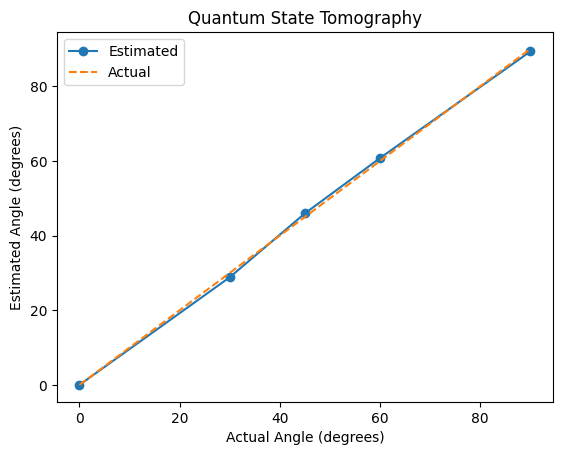

In [3]:
plt.plot(angles, estimated, marker='o', label='Estimated')
plt.plot(angles, angles, linestyle='--', label='Actual')

plt.xlabel("Actual Angle (degrees)")
plt.ylabel("Estimated Angle (degrees)")
plt.title("Quantum State Tomography")
plt.legend()
plt.show()

### Observation

The estimated rotation angles were close to the actual angles. Small differences
occur because quantum measurements are probabilistic. The graph shows that
measurement statistics can be used to reconstruct information about an unknown
quantum state.